In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference_utils as iu
import inference as inf

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import pyro.distributions as dist

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle
import jsonpickle as jpickle
import json
import gc

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

mask_file_name = "mask.txt"
processed_data_folder = os.path.join("processed_data")
mask_file = os.path.join(processed_data_folder, mask_file_name)

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

n_agents = int(full_data_df['subject'].max()+1)

recalc_measures = True

WAIC_max_samples = 100

num_steps = 600

In [4]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pickle.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9766)


/tmp/ipykernel_373919/1544998221.py:15: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  exp_mask = torch.tensor(all_mask).permute((1,0))


In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, use_h, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

In [7]:
def load_MFMB_results(learn_prior, use_orig, use_p, restrict_alpha, min_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, valid, remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

# Load participant data

In [8]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, 0)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, 0)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, 0)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)
possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)
possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ..., 

### load behavioral outputs of participants: mf-/mb-scores

In [9]:
scores_df = pd.read_csv(scores_file)

# Define agents

## BCC2 planning agent

In [10]:
# load BCC2 data

# set parameters and their names

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC2_p_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC2_p_agent_type)

BCC2_p_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_2pars_planning


## BCC4 planning repetition agent

In [11]:
# BCC4_planning_repetition agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_r_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_r_agent_type)

BCC4_p_r_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_repetition_weight


## BCC4 planning cached agent

In [12]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_c_agent_type)

BCC4_p_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_cached


## BCC6 planning repetition cached agent

In [13]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC6_p_r_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC6_p_r_c_agent_type)

BCC6_p_r_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_6pars_planning_repetition_weight_cached


## MFMB4 MF MB agent

In [14]:
# MFMB4 analysis

# set parameters and their names

learn_prior = False

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

max_dt = 6

# prepare for saving results
# make base filename and folder string
MFMB4_mf_mb_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB4_mf_mb_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


## MFMB6 MF MB agent & data

In [15]:
# MFMB6 analysis

# set parameters and their names

learn_prior = True

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
MFMB6_mf_mb_prior_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB6_mf_mb_prior_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


# Inference

## 1. BCC2 inference

In [16]:
# load BCC2 fitting of BCC2 data

BCC2_p_fname_base = BCC2_p_agent_type+"_inference_"
print(BCC2_p_fname_base)
# define folder where we want to save data
BCC2_p_base_dir = os.path.join(inference_folder,BCC2_p_fname_base[:-1])

BCC2_p_mean_df, BCC2_p_sample_df, BCC2_p_locs_df = \
    load_BCC_results(BCC2_p_agent_params["learn_rewards"], BCC2_p_agent_params["learn_habit"], 
                     BCC2_p_agent_params["learn_cached"], BCC2_p_agent_params["use_h"],
                     BCC2_p_base_dir, global_experiment_parameters, exp_mask, BCC2_p_fname_base, 
                     num_steps, data, BCC2_p_agent_params["param_names"])

BCC2_p_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC2_p_agent_params["learn_rewards"], BCC2_p_agent_params["learn_habit"], 
                                                    BCC2_p_agent_params["learn_cached"], BCC2_p_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC2_p_agent_params["use_h"])


BCC_2pars_planning_inference_
2
analyzing 188 data sets
2


/home/sarah/src/TwoStageStrategies/Chen_et_al_data/../code/BalancingControl/perception.py:142: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/

In [17]:
# calculate or load model comparison measure

fname_BCC2_p_WAIC = os.path.join(BCC2_p_base_dir, BCC2_p_fname_base+"_WAIC.json")

if recalc_measures:
    BCC2_p_WAIC = iu.calculate_waic(data, BCC2_p_agent, BCC2_p_locs_df, len(BCC2_p_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(BCC2_p_WAIC)
    with open(fname_BCC2_p_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_BCC2_p_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    BCC2_p_WAIC = jpickle.decode(pickled_WAIC)


In [18]:
# calculate or load model comparison measure

fname_BCC2_p_log_like = os.path.join(BCC2_p_base_dir, BCC2_p_fname_base+"_log_likelihood.json")

if recalc_measures:
    BCC2_p_log_like = iu.calculate_log_likelihood(data, BCC2_p_agent, BCC2_p_locs_df, len(BCC2_p_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like = jpickle.encode(BCC2_p_log_like)
    with open(fname_BCC2_p_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_BCC2_p_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    BCC2_p_log_like = jpickle.decode(pickled_log_like)


## 2. BCC4 planning repetition inference

In [19]:
# load BCC4 planning repetition fitting of BCC4 planning repetition data

BCC4_p_r_fname_base = BCC4_p_r_agent_type+"_inference_"
print(BCC4_p_r_fname_base)
# define folder where we want to save data
BCC4_p_r_base_dir = os.path.join(inference_folder,BCC4_p_r_fname_base[:-1])

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = \
    load_BCC_results(BCC4_p_r_agent_params["learn_rewards"], BCC4_p_r_agent_params["learn_habit"], 
                     BCC4_p_r_agent_params["learn_cached"], BCC4_p_r_agent_params["use_h"],
                     BCC4_p_r_base_dir, global_experiment_parameters, exp_mask, BCC4_p_r_fname_base, 
                     num_steps, data, BCC4_p_r_agent_params["param_names"])

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC4_p_r_agent_params["learn_rewards"], BCC4_p_r_agent_params["learn_habit"], 
                                                    BCC4_p_r_agent_params["learn_cached"], BCC4_p_r_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC4_p_r_agent_params["use_h"])

BCC_4pars_planning_repetition_weight_inference_
4
analyzing 188 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

In [20]:
# calculate or load model comparison measure

fname_BCC4_p_r_WAIC = os.path.join(BCC4_p_r_base_dir, BCC4_p_r_fname_base+"_WAIC.json")

if recalc_measures:
    BCC4_p_r_WAIC = iu.calculate_waic(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(BCC4_p_r_WAIC)
    with open(fname_BCC4_p_r_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_BCC4_p_r_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    BCC4_p_r_WAIC = jpickle.decode(pickled_WAIC)


In [21]:
# calculate or load model comparison measure

fname_BCC4_p_r_log_like = os.path.join(BCC4_p_r_base_dir, BCC4_p_r_fname_base+"_log_likelihood.json")

if recalc_measures:
    BCC4_p_r_log_like = iu.calculate_log_likelihood(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like = jpickle.encode(BCC4_p_r_log_like)
    with open(fname_BCC4_p_r_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_BCC4_p_r_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    BCC4_p_r_log_like = jpickle.decode(pickled_log_like)


## 3. BCC4 planning cached inference

In [22]:
# load BCC2 fitting of BCC2 data

BCC4_p_c_fname_base = BCC4_p_c_agent_type+"_inference_"
print(BCC4_p_c_fname_base)
# define folder where we want to save data
BCC4_p_c_base_dir = os.path.join(inference_folder,BCC4_p_c_fname_base[:-1])

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = \
    load_BCC_results(BCC4_p_c_agent_params["learn_rewards"], BCC4_p_c_agent_params["learn_habit"], 
                     BCC4_p_c_agent_params["learn_cached"], BCC4_p_c_agent_params["use_h"],
                     BCC4_p_c_base_dir, global_experiment_parameters, exp_mask, BCC4_p_c_fname_base, 
                     num_steps, data, BCC4_p_c_agent_params["param_names"])

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC4_p_c_agent_params["learn_rewards"], BCC4_p_c_agent_params["learn_habit"], 
                                                    BCC4_p_c_agent_params["learn_cached"], BCC4_p_c_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC4_p_c_agent_params["use_h"])


BCC_4pars_planning_cached_inference_
4
analyzing 188 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

In [23]:
# calculate or load model comparison measure

fname_BCC4_p_c_WAIC = os.path.join(BCC4_p_c_base_dir, BCC4_p_c_fname_base+"_WAIC.json")

if recalc_measures:
    BCC4_p_c_WAIC = iu.calculate_waic(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(BCC4_p_c_WAIC)
    with open(fname_BCC4_p_c_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_BCC4_p_c_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    BCC4_p_c_WAIC = jpickle.decode(pickled_WAIC)


In [24]:
# calculate or load model comparison measure

fname_BCC4_p_c_log_like = os.path.join(BCC4_p_c_base_dir, BCC4_p_c_fname_base+"_log_likelihood.json")

if recalc_measures:
    BCC4_p_c_log_like = iu.calculate_log_likelihood(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like= jpickle.encode(BCC4_p_c_log_like)
    with open(fname_BCC4_p_c_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_BCC4_p_c_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    BCC4_p_c_log_like = jpickle.decode(pickled_log_like)


## 4. BCC6 planning repetition cached inference

In [25]:
# load BCC2 fitting of BCC2 data

BCC6_p_r_c_fname_base = BCC6_p_r_c_agent_type+"_inference_"
print(BCC6_p_r_c_fname_base)
# define folder where we want to save data
BCC6_p_r_c_base_dir = os.path.join(inference_folder,BCC6_p_r_c_fname_base[:-1])

BCC6_p_r_c_mean_df, BCC6_p_r_c_sample_df, BCC6_p_r_c_locs_df = \
    load_BCC_results(BCC6_p_r_c_agent_params["learn_rewards"], BCC6_p_r_c_agent_params["learn_habit"], 
                     BCC6_p_r_c_agent_params["learn_cached"], BCC6_p_r_c_agent_params["use_h"],
                     BCC6_p_r_c_base_dir, global_experiment_parameters, exp_mask, BCC6_p_r_c_fname_base, 
                     num_steps, data, BCC6_p_r_c_agent_params["param_names"])

BCC6_p_r_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC6_p_r_c_agent_params["learn_rewards"], BCC6_p_r_c_agent_params["learn_habit"], 
                                                    BCC6_p_r_c_agent_params["learn_cached"], BCC6_p_r_c_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC6_p_r_c_agent_params["use_h"])


BCC_6pars_planning_repetition_weight_cached_inference_
6
analyzing 188 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

In [26]:
# calculate or load model comparison measure

fname_BCC6_p_r_c_WAIC = os.path.join(BCC6_p_r_c_base_dir, BCC6_p_r_c_fname_base+"_WAIC.json")

if recalc_measures:
    BCC6_p_r_c_WAIC = iu.calculate_waic(data, BCC6_p_r_c_agent, BCC6_p_r_c_locs_df, len(BCC6_p_r_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(BCC6_p_r_c_WAIC)
    with open(fname_BCC6_p_r_c_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_BCC6_p_r_c_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    BCC6_p_r_c_WAIC = jpickle.decode(pickled_WAIC)


In [27]:
# calculate or load model comparison measure

fname_BCC6_p_r_c_log_like = os.path.join(BCC6_p_r_c_base_dir, BCC6_p_r_c_fname_base+"_log_likelihood.json")

if recalc_measures:
    BCC6_p_r_c_log_like = iu.calculate_log_likelihood(data, BCC6_p_r_c_agent, BCC6_p_r_c_locs_df, len(BCC6_p_r_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like = jpickle.encode(BCC6_p_r_c_log_like)
    with open(fname_BCC6_p_r_c_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_BCC6_p_r_c_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    BCC6_p_r_c_log_like = jpickle.decode(pickled_log_like)


## 5. MFMB4 MF MB cached inference

In [28]:
MFMB4_mf_mb_fname_base = MFMB4_mf_mb_agent_type+"_inference_"
print(MFMB4_mf_mb_fname_base)
# define folder where we want to save data
MFMB4_mf_mb_base_dir = os.path.join(inference_folder,MFMB4_mf_mb_fname_base[:-1])

MFMB4_mf_mb_mean_df, MFMB4_mf_mb_sample_df, MFMB4_mf_mb_locs_df = \
    load_MFMB_results(MFMB4_mf_mb_agent_params["learn_prior"], MFMB4_mf_mb_agent_params["use_orig"], 
                      MFMB4_mf_mb_agent_params["use_p"], MFMB4_mf_mb_agent_params["restrict_alpha"], 
                      MFMB4_mf_mb_agent_params["min_alpha"], MFMB4_mf_mb_agent_params["max_dt"], 
                      MFMB4_mf_mb_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB4_mf_mb_fname_base, num_steps, 
                      data, MFMB4_mf_mb_agent_params["param_names"])

MFMB4_mf_mb_agent = tu.set_up_mbmf_inference_agent(n_agents, MFMB4_mf_mb_agent_params["learn_prior"], 
                                                          MFMB4_mf_mb_agent_params["use_orig"], MFMB4_mf_mb_agent_params["use_p"], 
                                                          MFMB4_mf_mb_agent_params["restrict_alpha"], MFMB4_mf_mb_agent_params["max_dt"], 
                                                          MFMB4_mf_mb_agent_params["min_alpha"], 
                                                          MFMB4_mf_mb_base_dir, global_experiment_parameters, data["valid"], remove_old=False)


MFMB_4pars_mf_mb_inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

In [29]:
# calculate or load model comparison measure

fname_MFMB4_mf_mb_WAIC = os.path.join(MFMB4_mf_mb_base_dir, MFMB4_mf_mb_fname_base+"_WAIC.json")

if recalc_measures:
    MFMB4_mf_mb_WAIC = iu.calculate_waic(data, MFMB4_mf_mb_agent, MFMB4_mf_mb_locs_df, len(MFMB4_mf_mb_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(MFMB4_mf_mb_WAIC)
    with open(fname_MFMB4_mf_mb_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_MFMB4_mf_mb_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    MFMB4_mf_mb_WAIC = jpickle.decode(pickled_WAIC)


In [30]:
# calculate or load model comparison measure

fname_MFMB4_mf_mb_log_like = os.path.join(MFMB4_mf_mb_base_dir, MFMB4_mf_mb_fname_base+"_log_likelihood.json")

if recalc_measures:
    MFMB4_mf_mb_log_like = iu.calculate_log_likelihood(data, MFMB4_mf_mb_agent, MFMB4_mf_mb_locs_df, len(MFMB4_mf_mb_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like = jpickle.encode(MFMB4_mf_mb_log_like)
    with open(fname_MFMB4_mf_mb_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_MFMB4_mf_mb_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    MFMB4_mf_mb_log_like = jpickle.decode(pickled_log_like)


## 6. MFMB4 MF MB prior cached inference

In [31]:

MFMB6_mf_mb_prior_fname_base = MFMB6_mf_mb_prior_agent_type+"_inference_"
print(MFMB6_mf_mb_prior_fname_base)
# define folder where we want to save data
MFMB6_mf_mb_prior_base_dir = os.path.join(inference_folder,MFMB6_mf_mb_prior_fname_base[:-1])

MFMB6_mf_mb_prior_mean_df, MFMB6_mf_mb_prior_sample_df, MFMB6_mf_mb_prior_locs_df = \
    load_MFMB_results(MFMB6_mf_mb_prior_agent_params["learn_prior"], MFMB6_mf_mb_prior_agent_params["use_orig"], 
                      MFMB6_mf_mb_prior_agent_params["use_p"], MFMB6_mf_mb_prior_agent_params["restrict_alpha"], 
                      MFMB6_mf_mb_prior_agent_params["min_alpha"], MFMB6_mf_mb_prior_agent_params["max_dt"], 
                      MFMB6_mf_mb_prior_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB6_mf_mb_prior_fname_base, num_steps, 
                      data, MFMB6_mf_mb_prior_agent_params["param_names"])

MFMB6_mf_mb_prior_agent = tu.set_up_mbmf_inference_agent(n_agents, MFMB6_mf_mb_prior_agent_params["learn_prior"], 
                                                          MFMB6_mf_mb_prior_agent_params["use_orig"], MFMB6_mf_mb_prior_agent_params["use_p"], 
                                                          MFMB6_mf_mb_prior_agent_params["restrict_alpha"], MFMB6_mf_mb_prior_agent_params["max_dt"], 
                                                          MFMB6_mf_mb_prior_agent_params["min_alpha"], 
                                                          MFMB6_mf_mb_prior_base_dir, global_experiment_parameters, data["valid"], remove_old=False)


MFMB_6pars_mf_mb_prior_inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

In [32]:
# calculate or load model comparison measure

fname_MFMB6_mf_mb_prior_WAIC = os.path.join(MFMB6_mf_mb_prior_base_dir, MFMB6_mf_mb_prior_fname_base+"_WAIC.json")

if recalc_measures:
    MFMB6_mf_mb_prior_WAIC = iu.calculate_waic(data, MFMB6_mf_mb_prior_agent, MFMB6_mf_mb_prior_locs_df, len(MFMB6_mf_mb_prior_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=WAIC_max_samples)

    pickled_WAIC = jpickle.encode(MFMB6_mf_mb_prior_WAIC)
    with open(fname_MFMB6_mf_mb_prior_WAIC, 'w') as outfile:
        json.dump(pickled_WAIC, outfile)
    
else:

    with open(fname_MFMB6_mf_mb_prior_WAIC, 'r') as infile:
        pickled_WAIC = json.load(infile)
    MFMB6_mf_mb_prior_WAIC = jpickle.decode(pickled_WAIC)


In [33]:
# calculate or load model comparison measure

fname_MFMB6_mf_mb_prior_log_like = os.path.join(MFMB6_mf_mb_prior_base_dir, MFMB6_mf_mb_prior_fname_base+"_log_like.json")

if recalc_measures:
    MFMB6_mf_mb_prior_log_like = iu.calculate_log_likelihood(data, MFMB6_mf_mb_prior_agent, MFMB6_mf_mb_prior_locs_df, len(MFMB6_mf_mb_prior_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

    pickled_log_like = jpickle.encode(MFMB6_mf_mb_prior_log_like)
    with open(fname_MFMB6_mf_mb_prior_log_like, 'w') as outfile:
        json.dump(pickled_log_like, outfile)
    
else:

    with open(fname_MFMB6_mf_mb_prior_log_like, 'r') as infile:
        pickled_log_like = json.load(infile)
    MFMB6_mf_mb_prior_log_like = jpickle.decode(pickled_log_like)


# Get all WAICs

In [34]:
all_total_WAICs = torch.stack([BCC2_p_WAIC, BCC4_p_r_WAIC, 
                                           BCC4_p_c_WAIC, BCC6_p_r_c_WAIC,
                                           MFMB4_mf_mb_WAIC, MFMB6_mf_mb_prior_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())
print("MFMB4 MF MB wins", (winning_model==4).sum())
print("MFMB6 MF MP Prior wins", (winning_model==5).sum())

p_model = torch.nn.functional.softmax(-all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_WAICs)

BCC2 planning wins tensor(10)
BCC4 planning repetition wins tensor(0)
BCC4 planning cached wins tensor(1)
BCC6 planning repetition cached repetition wins tensor(0)
MFMB4 MF MB wins tensor(130)
MFMB6 MF MP Prior wins tensor(47)
torch.Size([188, 6])
tensor([5.3684e-02, 1.0599e-10, 5.3223e-03, 4.5273e-21, 6.9879e-01, 2.4220e-01])
tensor([0., 0., 0., 0., 1., 0.])
p model mean according to measure tensor([5.3684e-02, 1.0599e-10, 5.3223e-03, 4.5273e-21, 6.9879e-01, 2.4220e-01])
best model: tensor(4) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(347.00140613149705), pvalue=np.float64(0.0), df=np.int64(499))


# Get all BCC WAICs

In [35]:
all_total_WAICs = torch.stack([BCC2_p_WAIC, BCC4_p_r_WAIC, 
                                           BCC4_p_c_WAIC, BCC6_p_r_c_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())

p_model = torch.nn.functional.softmax(-all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_WAICs)

BCC2 planning wins tensor(35)
BCC4 planning repetition wins tensor(23)
BCC4 planning cached wins tensor(79)
BCC6 planning repetition cached repetition wins tensor(51)
torch.Size([188, 4])
tensor([0.1860, 0.1236, 0.4168, 0.2737])
tensor([0., 0., 1., 0.])
p model mean according to measure tensor([0.1860, 0.1236, 0.4168, 0.2737])
best model: tensor(2) exceedance prob tensor(0.9800)
is significantly different from uniform? TtestResult(statistic=np.float64(96.28695460317722), pvalue=np.float64(0.0), df=np.int64(499))


# Get BCC+MFMB4 WAICs

In [36]:
all_total_WAICs = torch.stack([BCC2_p_WAIC, BCC4_p_r_WAIC, 
                                           BCC4_p_c_WAIC, BCC6_p_r_c_WAIC,
                                           MFMB4_mf_mb_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())
print("MFMB4 MF MB wins", (winning_model==4).sum())

p_model = torch.nn.functional.softmax(-all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_WAICs)

BCC2 planning wins tensor(11)
BCC4 planning repetition wins tensor(0)
BCC4 planning cached wins tensor(3)
BCC6 planning repetition cached repetition wins tensor(0)
MFMB4 MF MB wins tensor(174)
torch.Size([188, 5])
tensor([6.1182e-02, 8.6667e-05, 1.3699e-02, 9.8538e-20, 9.2503e-01])
tensor([0., 0., 0., 0., 1.])
p model mean according to measure tensor([6.1182e-02, 8.6667e-05, 1.3699e-02, 9.8538e-20, 9.2503e-01])
best model: tensor(4) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(813.9055255243788), pvalue=np.float64(0.0), df=np.int64(499))


# Get BCC6+MFMB4 WAICs

In [37]:
all_total_WAICs = torch.stack([BCC6_p_r_c_WAIC,
                                           MFMB4_mf_mb_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC6 planning repetition cached repetition wins", (winning_model==0).sum())
print("MFMB4 MF MB wins", (winning_model==1).sum())

p_model = torch.nn.functional.softmax(-all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_WAICs)

BCC6 planning repetition cached repetition wins tensor(1)
MFMB4 MF MB wins tensor(187)
torch.Size([188, 2])
tensor([0.0045, 0.9955])
tensor([0., 1.])
p model mean according to measure tensor([0.0045, 0.9955])
best model: tensor(1) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(2435.889645547593), pvalue=np.float64(0.0), df=np.int64(499))


# Get all Log Likelihoodss

In [38]:
all_total_log_likes = torch.stack([BCC2_p_log_like, BCC4_p_r_log_like, 
                                           BCC4_p_c_log_like, BCC6_p_r_c_log_like,
                                           MFMB4_mf_mb_log_like, MFMB6_mf_mb_prior_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())
print("MFMB4 MF MB wins", (winning_model==4).sum())
print("MFMB6 MF MP Prior wins", (winning_model==5).sum())

p_model = torch.nn.functional.softmax(-all_total_log_likes, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_log_likes.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_log_likes)

BCC2 planning wins tensor(6)
BCC4 planning repetition wins tensor(3)
BCC4 planning cached wins tensor(4)
BCC6 planning repetition cached repetition wins tensor(1)
MFMB4 MF MB wins tensor(123)
MFMB6 MF MP Prior wins tensor(51)
torch.Size([188, 6])
tensor([0.0365, 0.0155, 0.0247, 0.0087, 0.6205, 0.2940])
tensor([0., 0., 0., 0., 1., 0.])
p model mean according to measure tensor([0.0365, 0.0155, 0.0247, 0.0087, 0.6205, 0.2940])
best model: tensor(4) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(296.3959378458499), pvalue=np.float64(0.0), df=np.int64(499))


# Get all BCC+MFMB4 Likelihoodss

In [39]:
all_total_log_likes = torch.stack([BCC2_p_log_like, BCC4_p_r_log_like, 
                                           BCC4_p_c_log_like, BCC6_p_r_c_log_like,
                                           MFMB4_mf_mb_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())
print("MFMB4 MF MB wins", (winning_model==4).sum())

p_model = torch.nn.functional.softmax(-all_total_log_likes, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_log_likes.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_log_likes)

BCC2 planning wins tensor(6)
BCC4 planning repetition wins tensor(5)
BCC4 planning cached wins tensor(4)
BCC6 planning repetition cached repetition wins tensor(1)
MFMB4 MF MB wins tensor(172)
torch.Size([188, 5])
tensor([0.0378, 0.0272, 0.0255, 0.0120, 0.8976])
tensor([0., 0., 0., 0., 1.])
p model mean according to measure tensor([0.0378, 0.0272, 0.0255, 0.0120, 0.8976])
best model: tensor(4) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(756.3930514165866), pvalue=np.float64(0.0), df=np.int64(499))


# Get all BCC Log Likelihoodss

In [40]:
all_total_log_likes = torch.stack([BCC2_p_log_like, BCC4_p_r_log_like, 
                                           BCC4_p_c_log_like, BCC6_p_r_c_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC2 planning wins", (winning_model==0).sum())
print("BCC4 planning repetition wins", (winning_model==1).sum())
print("BCC4 planning cached wins", (winning_model==2).sum())
print("BCC6 planning repetition cached repetition wins", (winning_model==3).sum())

p_model = torch.nn.functional.softmax(-all_total_log_likes, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_log_likes.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_log_likes)

BCC2 planning wins tensor(18)
BCC4 planning repetition wins tensor(36)
BCC4 planning cached wins tensor(31)
BCC6 planning repetition cached repetition wins tensor(103)
torch.Size([188, 4])
tensor([0.0890, 0.1973, 0.1668, 0.5470])
tensor([0., 0., 0., 1.])
p model mean according to measure tensor([0.0890, 0.1973, 0.1668, 0.5470])
best model: tensor(3) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(177.69584229180896), pvalue=np.float64(0.0), df=np.int64(499))


# Get all BCC6+MFMB4 Likelihoodss

In [41]:
all_total_log_likes = torch.stack([BCC6_p_r_c_log_like,
                                           MFMB4_mf_mb_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC6 planning repetition cached repetition wins", (winning_model==0).sum())
print("MFMB4 MF MB wins", (winning_model==1).sum())

p_model = torch.nn.functional.softmax(-all_total_log_likes, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-all_total_log_likes.sum(dim=0), dim=-1)

print(p_model_total)

iu.calculate_exceedance_prob(-all_total_log_likes)

BCC6 planning repetition cached repetition wins tensor(4)
MFMB4 MF MB wins tensor(184)
torch.Size([188, 2])
tensor([0.0285, 0.9715])
tensor([0., 1.])
p model mean according to measure tensor([0.0285, 0.9715])
best model: tensor(1) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(805.2105643578686), pvalue=np.float64(0.0), df=np.int64(499))


In [46]:
all_measures = torch.cat([BCC2_p_WAIC, BCC4_p_r_WAIC, BCC4_p_c_WAIC, BCC6_p_r_c_WAIC, MFMB4_mf_mb_WAIC, #MFMB6_mf_mb_prior_WAIC, \
                        BCC2_p_log_like, BCC4_p_r_log_like, BCC4_p_c_log_like, BCC6_p_r_c_log_like, MFMB4_mf_mb_log_like, #MFMB6_mf_mb_prior_log_like\
                            ], dim=0)

measure_types = ["WAIC"]*n_agents*5 + ["log like"]*n_agents*5 #6

model_types = (["BCC2 plan"]*n_agents + ["BCC4 plan rep"]*n_agents + ["BCC4 plan cache"]*n_agents + ["BCC6 plan rep cache"]*n_agents + ["MFMB4 mb mf"]*n_agents)*2 #, "MFMB6 mb mf prior"

all_measures_df = pd.DataFrame({"measure": all_measures, "type": measure_types, "model": model_types})

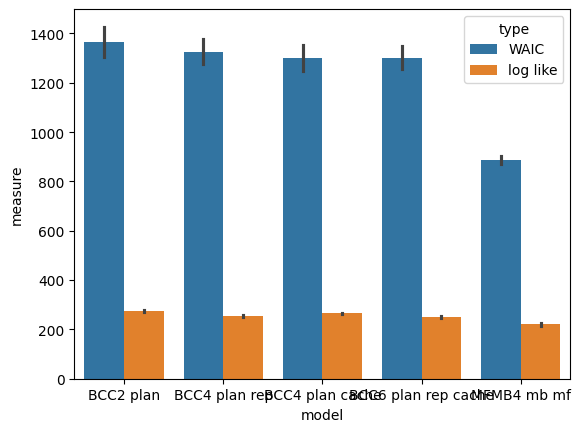

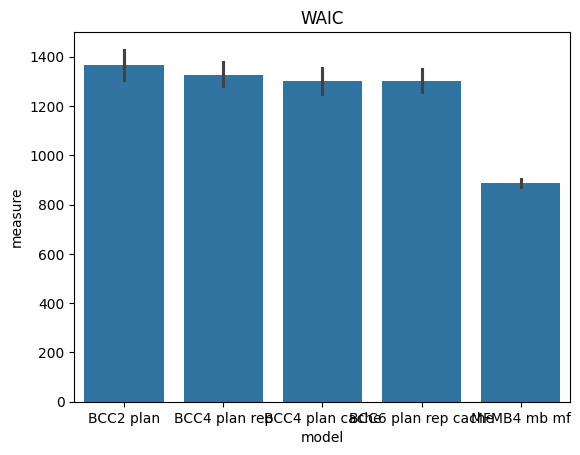

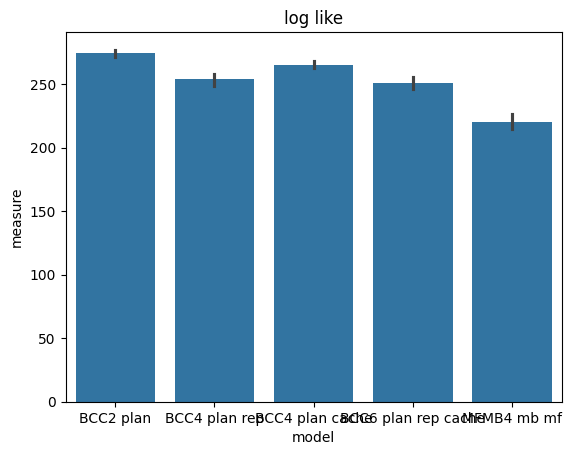

In [47]:
plt.figure()
sns.barplot(data=all_measures_df, y="measure", x="model", hue="type")
plt.show()

plt.figure()
plt.title("WAIC")
sns.barplot(data=all_measures_df[all_measures_df["type"]=="WAIC"], y="measure", x="model")
plt.show()

plt.figure()
plt.title("log like")
sns.barplot(data=all_measures_df[all_measures_df["type"]=="log like"], y="measure", x="model")
plt.show()

In [48]:
BCC_measures = torch.cat([BCC2_p_WAIC, BCC4_p_r_WAIC, BCC4_p_c_WAIC, BCC6_p_r_c_WAIC, 
                        BCC2_p_log_like, BCC4_p_r_log_like, BCC4_p_c_log_like, BCC6_p_r_c_log_like, 
                            ], dim=0)

measure_types = ["WAIC"]*n_agents*4 + ["log like"]*n_agents*4 #6

model_types = (["BCC2 plan"]*n_agents + ["BCC4 plan rep"]*n_agents + ["BCC4 plan cache"]*n_agents + ["BCC6 plan rep cache"]*n_agents)*2 

BCC_measures_df = pd.DataFrame({"measure": BCC_measures, "type": measure_types, "model": model_types})

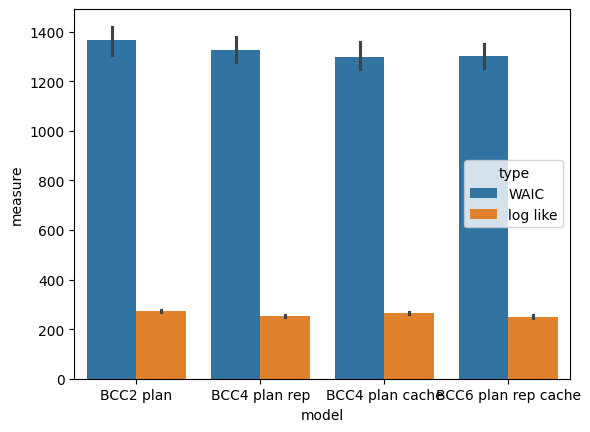

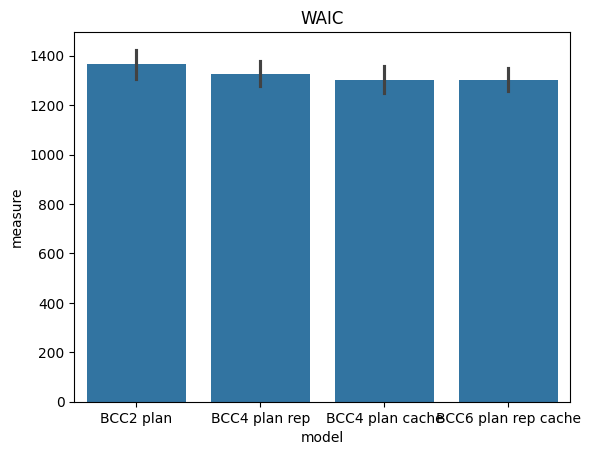

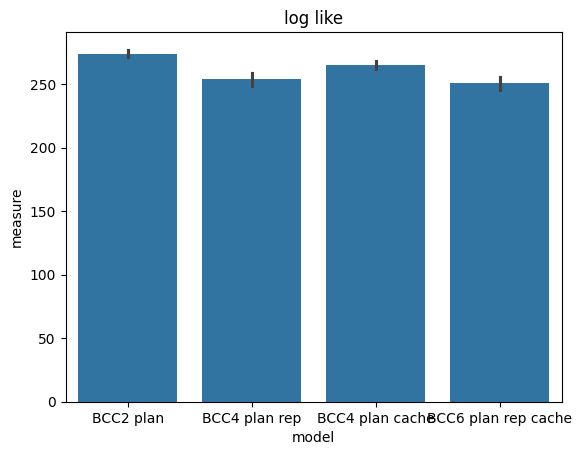

In [49]:
plt.figure()
sns.barplot(data=BCC_measures_df, y="measure", x="model", hue="type")
plt.show()

plt.figure()
plt.title("WAIC")
sns.barplot(data=BCC_measures_df[BCC_measures_df["type"]=="WAIC"], y="measure", x="model")
plt.show()

plt.figure()
plt.title("log like")
sns.barplot(data=BCC_measures_df[BCC_measures_df["type"]=="log like"], y="measure", x="model")
plt.show()

In [55]:
BCC6_MFMB4_measures = torch.cat([BCC6_p_r_c_WAIC, MFMB4_mf_mb_WAIC, 
                                BCC6_p_r_c_log_like, MFMB4_mf_mb_log_like
                            ], dim=0)

measure_types = ["WAIC"]*n_agents*2 + ["log like"]*n_agents*2 #6

model_types = (["BCC6 plan rep cache"]*n_agents + ["MFMB4 mb mf"]*n_agents)*2 

BCC6_MFMB4_measures_df = pd.DataFrame({"measure": BCC6_MFMB4_measures, "type": measure_types, "model": model_types})

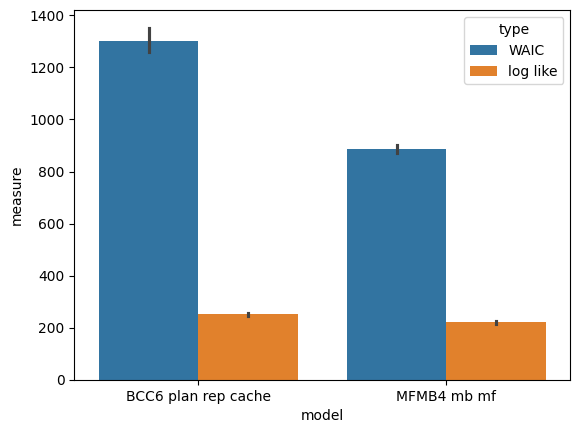

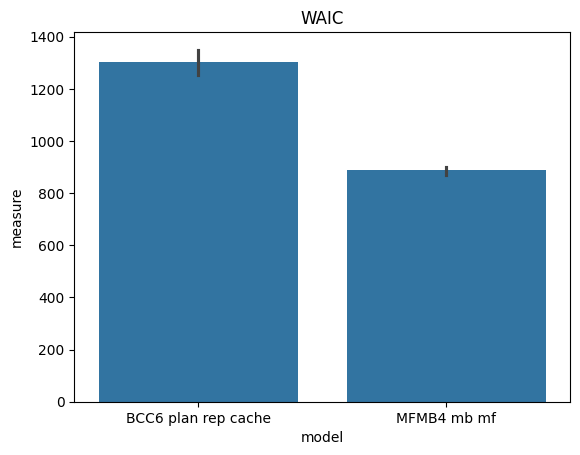

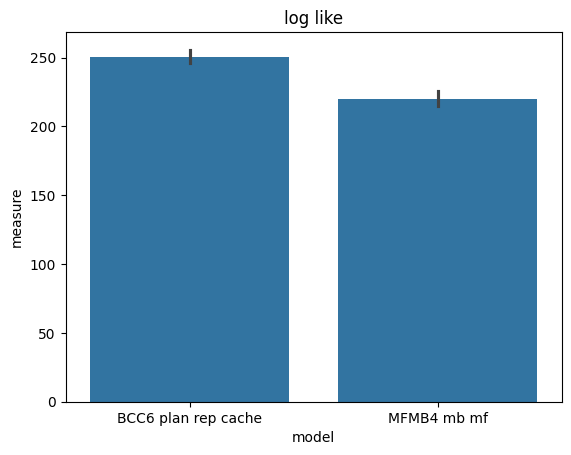

In [56]:
plt.figure()
sns.barplot(data=BCC6_MFMB4_measures_df, y="measure", x="model", hue="type")
plt.show()

plt.figure()
plt.title("WAIC")
sns.barplot(data=BCC6_MFMB4_measures_df[BCC6_MFMB4_measures_df["type"]=="WAIC"], y="measure", x="model")
plt.show()

plt.figure()
plt.title("log like")
sns.barplot(data=BCC6_MFMB4_measures_df[BCC6_MFMB4_measures_df["type"]=="log like"], y="measure", x="model")
plt.show()